#AI4S FINANCIAL ADVICE

##0.REFERENCE

https://claude.ai/share/8b0f3607-44cc-4907-99ba-b5e694ac7179

##1.CONTEXT



Wealth planning is, at its core, an optimisation problem under uncertainty. A
household arrives with income, assets, debts, and a set of ranked goals —
retirement security, college funding, a vacation property — and the task is to
find an investment strategy that maximises the probability of reaching all of
those goals within the constraints of their risk tolerance, time horizon, and
liquidity needs. That framing maps precisely onto the **AI for Science (AI4S)**
paradigm: a system that proposes candidate solutions, simulates their outcomes
across hundreds of possible futures, learns from scenarios where the strategy
fails, and refines its proposals accordingly. The market replaces the laboratory.
Monte Carlo paths replace experiments. Goal attainment probability replaces
reaction yield.

The critical difference from a standard financial model is the word *ranked*.
Most optimisers treat goals as interchangeable — maximise total expected wealth
subject to a risk constraint. Real clients do not experience their goals that way.
Retirement security is not the same kind of goal as a vacation home. One is
non-negotiable and carries thirty years of income dependency; the other is
aspirational and can be deferred or eliminated. A system that treats them
symmetrically will propose strategies that look efficient on paper but fail the
client in the scenario that actually matters most.

This notebook applies the AI4S framework to Sam and Taylor Reeves — a dual-income
household with a specific, non-trivial financial situation. Their total portfolio
stands at 1.33 million, but it has drifted badly: the taxable account is
concentrated in three technology stocks that represent over forty percent of that
account's value, $85,000 is sitting in a savings account earning fifty basis
points, Sam's 401k has not been rebalanced in three years and is almost certainly
over seventy percent equity, and both Roth IRA contribution streams were halted
two years ago. Against a retirement target of 3.6 million in fifteen years, a
college funding target of 640,000 in eight years, and a vacation home down
payment target of 195,000 in seven years, the baseline simulation shows a
weighted goal attainment probability that leaves significant room for improvement.
The gap is not hopeless. It is exactly the kind of problem that disciplined,
multi-period strategy can address — if the strategies are evaluated honestly.

The system has three components. `WealthStrategyLoop` runs one complete research
cycle: it generates candidate investment strategies via Claude, passes them through
a suitability gate that checks fiduciary compliance, runs 1,000 Monte Carlo
simulations of each strategy across a fifteen-year horizon, evaluates the
probability of meeting each ranked goal separately, stress-tests the best strategy
under a market crash, an inflation spike, and a sequence-of-returns scenario, and
produces a structured feedback diagnosis. `WealthEvaluationAgent` governs multiple
cycles, accumulating failure context between rounds and deciding whether to continue
searching or deploy the best plan found.

The third component is `AdvisorReviewAgent`, which simulates Robert Okafor, a
Senior Certified Financial Planner with twenty-two years of practice. Claude plays
Robert reviewing every AI recommendation before it can proceed. He asks three
questions that pure optimisation cannot answer: Is this strategy genuinely better
than doing nothing? Will Sam and Taylor actually stick to it behaviourally? Are
the fees justified relative to index alternatives? His review returns not just
modifications but also behavioural warnings — emotional and cognitive risks to flag
with the clients directly — and re-plan triggers specifying which life events should
prompt a full strategy review. These are professional judgment calls that belong to
the advisor, not the algorithm.

The suitability gate enforces the fiduciary standard before any strategy reaches
the simulation engine. A strategy that violates the concentration limit, recommends
illiquid products beyond the regulatory threshold, or proposes leverage for a
moderate-risk client is flagged as unsuitable and excluded. The simulation engine
never produces an expected-value number for an unsuitable strategy.

The market universe, asset class parameters, and regulatory rules used here are
synthetic. Nothing in this notebook constitutes investment advice or a solicitation
to buy or sell any security. Robert Okafor is a simulated persona. The purpose is
to show how the AI4S loop — propose, simulate, advise, decide — can operate in a
domain where numerical rigour and human judgment must work together, neither
replacing the other.

---




**Architecture**

```
WealthEvaluationAgent  (governs up to 3 research cycles)
  |
  +--> WealthStrategyLoop.run()  --> CycleResult
         |                                  |
         | generate strategies (Claude)     |
         | suitability gate -- fiduciary    |
         | Monte Carlo simulation           |
         | goal attainment analysis         |
         | stress test -- market scenarios  |
         | shadow portfolio tracking        |
         | get feedback (Claude)            |
                                            |
  +--> AdvisorReviewAgent.review()  <-------+
         | Claude plays Robert Okafor, CFP
         | APPROVE / APPROVE_WITH_MODS / REJECT
         |
  +--> WealthEvaluationAgent decides:
         CONTINUE / STOP_SUCCESS / STOP_MAX_ROUNDS
```

| Cell | Content |
|------|---------|
| 1 | Setup |
| 2 | Synthetic market universe (asset classes, products, regulations) |
| 3 | Client profile and ranked goals |
| 4 | Monte Carlo engine and goal attainment simulator |
| 5 | `WealthStrategyLoop` class |
| 6 | `AdvisorReviewAgent` class |
| 7 | `WealthEvaluationAgent` class |
| 8 | Orchestrator |
| 9 | Final wealth plan dashboard |


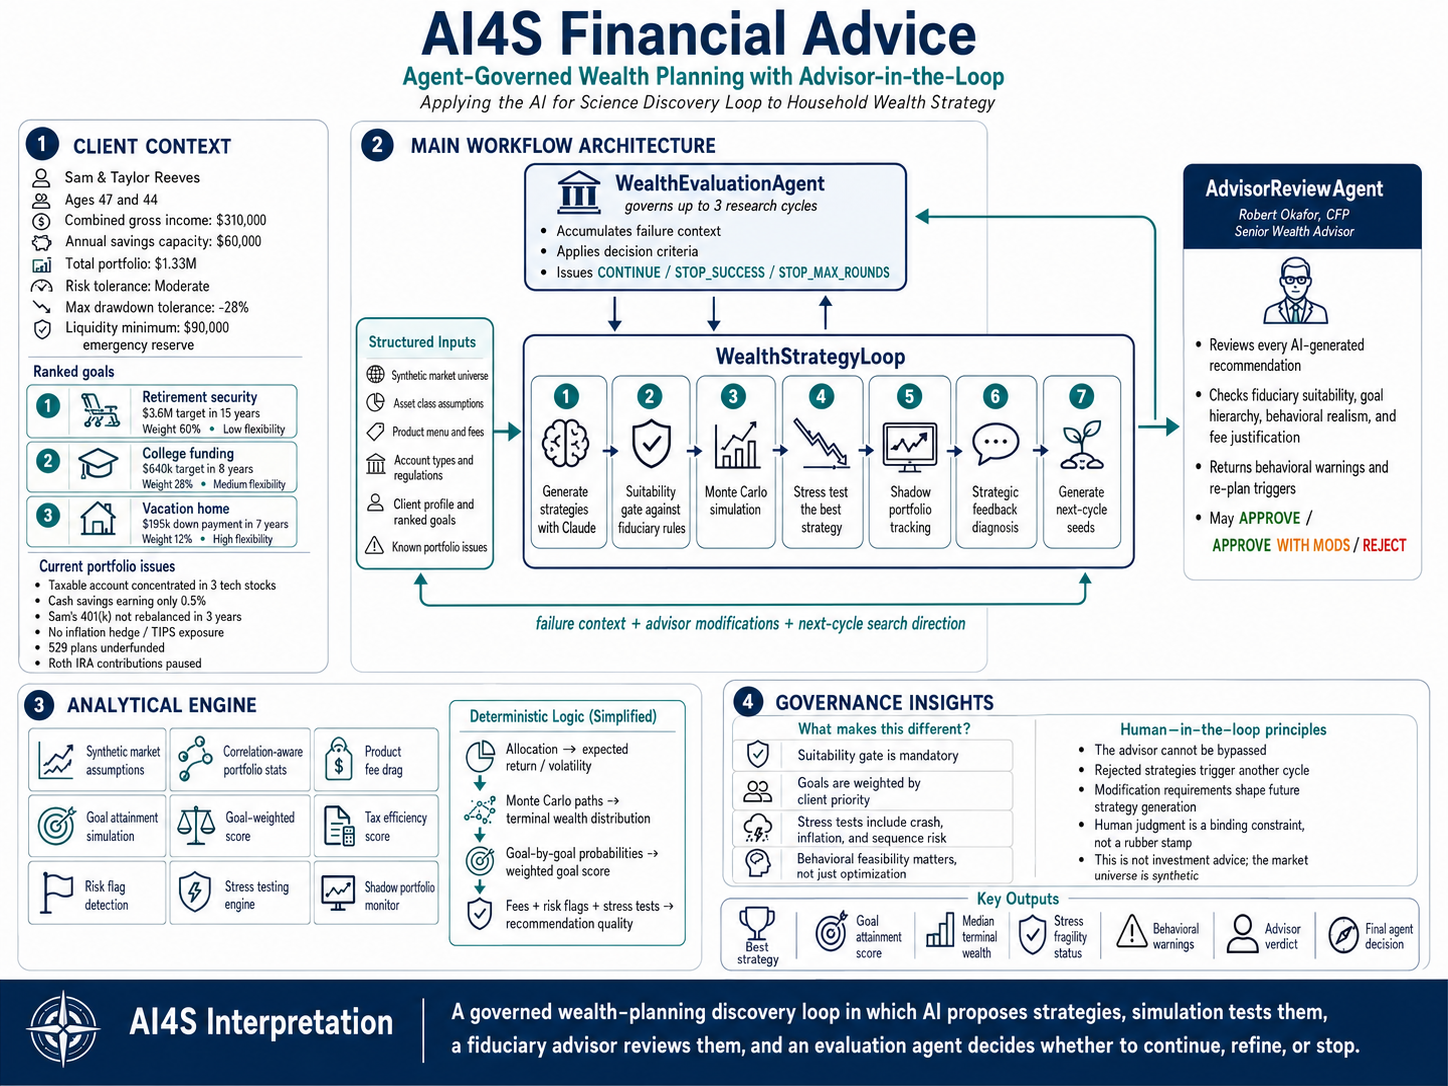

---

##2.CODE AND IMPLEMENTATION

In [22]:
# CELL 1  SETUP
# -----------------------------------------------------------------------
!pip install anthropic --quiet

import json, warnings
from dataclasses import dataclass, field
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google.colab import userdata
import anthropic

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

API_KEY = userdata.get('ANTHROPIC_API_KEY')
CLIENT  = anthropic.Anthropic(api_key=API_KEY)
MODEL   = 'claude-haiku-4-5-20251001'

def ask_claude(system, user, max_tokens=1200):
    msg = CLIENT.messages.create(
        model=MODEL, max_tokens=max_tokens,
        system=system,
        messages=[{'role': 'user', 'content': user}]
    )
    return msg.content[0].text.strip()

def parse_json(raw):
    clean = raw.strip().replace('```json','').replace('```','')
    return json.loads(clean.strip())

print('Setup complete -- model:', MODEL)

Setup complete -- model: claude-haiku-4-5-20251001


In [23]:
# CELL 2  SYNTHETIC MARKET UNIVERSE
# Asset classes, products, fee structures, regulatory constraints.
# -----------------------------------------------------------------------

MARKET_UNIVERSE = {
    'name': 'Synthetic Capital Markets v1.0',

    # -- Asset class return / vol assumptions (annualised) ---------------
    'asset_classes': {
        'us_large_cap_equity':  {'mu': 0.097, 'sigma': 0.162, 'label': 'US Large Cap'},
        'us_small_cap_equity':  {'mu': 0.110, 'sigma': 0.210, 'label': 'US Small Cap'},
        'intl_developed_equity':{'mu': 0.082, 'sigma': 0.175, 'label': 'Intl Developed'},
        'emerging_market_equity':{'mu': 0.105,'sigma': 0.240, 'label': 'Emerging Mkt'},
        'us_agg_bond':          {'mu': 0.042, 'sigma': 0.055, 'label': 'US Agg Bond'},
        'tips':                 {'mu': 0.030, 'sigma': 0.060, 'label': 'TIPS'},
        'high_yield_bond':      {'mu': 0.058, 'sigma': 0.110, 'label': 'High Yield'},
        'real_estate_reit':     {'mu': 0.090, 'sigma': 0.190, 'label': 'REITs'},
        'commodities':          {'mu': 0.040, 'sigma': 0.180, 'label': 'Commodities'},
        'cash_equivalents':     {'mu': 0.045, 'sigma': 0.008, 'label': 'Cash / MM'},
    },

    # -- Correlation matrix (simplified key pairs) ----------------------
    'key_correlations': {
        ('us_large_cap_equity','us_small_cap_equity'):    0.82,
        ('us_large_cap_equity','intl_developed_equity'):  0.74,
        ('us_large_cap_equity','us_agg_bond'):           -0.10,
        ('us_large_cap_equity','high_yield_bond'):        0.55,
        ('us_large_cap_equity','real_estate_reit'):       0.65,
        ('us_agg_bond','tips'):                           0.85,
        ('us_large_cap_equity','commodities'):            0.15,
    },

    # -- Investment products available ----------------------------------
    'products': {
        'index_etf':        {'expense_ratio': 0.0010, 'min_investment': 1,
                             'liquid': True,  'tax_efficient': True},
        'active_mutual_fund':{'expense_ratio': 0.0075,'min_investment': 1000,
                             'liquid': True,  'tax_efficient': False},
        'target_date_fund': {'expense_ratio': 0.0015, 'min_investment': 1000,
                             'liquid': True,  'tax_efficient': False},
        'annuity_variable':  {'expense_ratio': 0.0200, 'min_investment': 10000,
                             'liquid': False, 'surrender_period_yrs': 7},
        'individual_bond':   {'expense_ratio': 0.0005, 'min_investment': 5000,
                             'liquid': True,  'tax_efficient': True},
        'private_equity':    {'expense_ratio': 0.0200, 'min_investment': 250000,
                             'liquid': False, 'lock_up_yrs': 10,
                             'accredited_investor_required': True},
    },

    # -- Account types --------------------------------------------------
    'account_types': {
        '401k':      {'contribution_limit': 23_000, 'employer_match': True,
                      'tax_treatment': 'pre_tax', 'rmd_at': 73},
        'roth_ira':  {'contribution_limit': 7_000,  'income_limit_mfj': 240_000,
                      'tax_treatment': 'post_tax_grow_tax_free', 'rmd_at': None},
        'trad_ira':  {'contribution_limit': 7_000,  'deductible': 'income_tested',
                      'tax_treatment': 'pre_tax', 'rmd_at': 73},
        '529_plan':  {'contribution_limit': 18_000, 'tax_treatment': 'education_tax_free',
                      'penalty_if_non_edu': 0.10},
        'taxable':   {'contribution_limit': None, 'tax_treatment': 'ltcg_rates',
                      'harvesting_allowed': True},
        'hsa':       {'contribution_limit': 8_300,  'tax_treatment': 'triple_tax',
                      'requires_hdhp': True},
    },

    # -- Regulatory / suitability framework ----------------------------
    'regulations': {
        'fiduciary_standard':  'Best interest of client at all times.',
        'suitability_rule_4':  'Recommendations must match risk tolerance, '
                               'time horizon, and liquidity needs.',
        'fee_disclosure':      'All fees must be disclosed; no hidden incentives.',
        'concentration_limit': 'No single security > 20% of investable assets.',
        'illiquid_limit':      'Illiquid assets <= 15% of portfolio for non-accredited.',
        'leverage_rule':       'No margin or leverage for conservative/moderate clients.',
        'churning_rule':       'No excessive trading; must justify each rebalance.',
        'accredited_investor':  'Income > $200k individual or net worth > $1M ex-primary.',
    },

    # -- Inflation and tax assumptions ----------------------------------
    'inflation_rate':       0.030,
    'ltcg_rate_mfj':        0.150,
    'ordinary_income_rate': 0.280,   # synthetic marginal rate for this client
    'safe_withdrawal_rate': 0.040,
}

print('Market universe loaded:')
print(f'  Asset classes : {len(MARKET_UNIVERSE["asset_classes"])}')
print(f'  Products      : {len(MARKET_UNIVERSE["products"])}')
print(f'  Account types : {len(MARKET_UNIVERSE["account_types"])}')
print(f'  Inflation     : {MARKET_UNIVERSE["inflation_rate"]:.1%}')
print(f'  Safe withdraw : {MARKET_UNIVERSE["safe_withdrawal_rate"]:.1%}')

Market universe loaded:
  Asset classes : 10
  Products      : 6
  Account types : 6
  Inflation     : 3.0%
  Safe withdraw : 4.0%


In [24]:
# CELL 3  CLIENT PROFILE AND RANKED GOALS
# Meet Sam and Taylor Reeves -- dual income, three competing goals,
# and a portfolio that has drifted significantly from any coherent plan.
# -----------------------------------------------------------------------

CLIENT_PROFILE = {
    'name':           'Sam & Taylor Reeves',
    'ages':           (47, 44),
    'filing_status':  'mfj',

    # -- Income ----------------------------------------------------------
    'gross_income':       310_000,    # combined W-2
    'after_tax_income':   215_000,    # estimated take-home
    'annual_savings_cap': 60_000,     # max they can invest per year

    # -- Current portfolio -----------------------------------------------
    'portfolio': {
        '401k_sam':         480_000,   # mostly large cap, no rebalance in 3yr
        '401k_taylor':      310_000,   # target date 2040
        'roth_ira_sam':      95_000,   # aggressive growth
        'roth_ira_taylor':   78_000,   # aggressive growth
        'taxable_account':  220_000,   # individual stocks, concentrated
        'cash_savings':      85_000,   # earning 0.5% -- drag
        '529_child1':        42_000,
        '529_child2':        18_000,
    },

    # -- Current allocation (approximate) --------------------------------
    'current_allocation': {
        'us_large_cap_equity':   0.58,
        'us_small_cap_equity':   0.04,
        'intl_developed_equity': 0.06,
        'us_agg_bond':           0.08,
        'cash_equivalents':      0.24,  # over-allocated to cash
    },

    # -- RANKED GOALS (1 = highest priority) ----------------------------
    'goals': [
        {
            'rank':          1,
            'name':          'retirement_security',
            'description':   'Retire at age 62 (Sam) with $12,000/month '
                             'real income for 30 years.',
            'target_amount': 3_600_000,   # PV of income stream at retirement
            'years_to_goal': 15,
            'flexibility':   'low',        # non-negotiable
        },
        {
            'rank':          2,
            'name':          'college_funding',
            'description':   'Fund 4-year college for both children '
                             '($80,000/year in today dollars).',
            'target_amount': 640_000,     # total in today dollars
            'years_to_goal': 8,           # first child starts in 8 years
            'flexibility':   'medium',
        },
        {
            'rank':          3,
            'name':          'vacation_home',
            'description':   'Purchase $650,000 vacation property in 7 years.',
            'target_amount': 195_000,     # 30% down payment target
            'years_to_goal': 7,
            'flexibility':   'high',      # nice to have
        },
    ],

    # -- Risk profile ----------------------------------------------------
    'risk_tolerance':    'moderate',
    'risk_score':        58,             # out of 100
    'max_drawdown_tol':  -0.28,          # most they can stomach
    'liquidity_needed':  90_000,         # 6-month emergency fund minimum
    'is_accredited':     True,           # income qualifies
    'investment_horizon': 15,            # years to primary goal

    # -- Current problems ------------------------------------------------
    'known_issues': [
        'Taxable account concentrated in 3 tech stocks (>40% of that account).',
        'Cash earning 0.5% -- significant opportunity cost vs money market.',
        '401k (Sam) not rebalanced in 3 years -- likely over 70% equity.',
        'No TIPS or inflation hedge in portfolio.',
        'College 529 underfunded by ~$200,000 at current pace.',
        'Roth IRA contributions stopped 2 years ago.',
    ],
}

total_portfolio = sum(CLIENT_PROFILE['portfolio'].values())
total_goals     = sum(g['target_amount'] for g in CLIENT_PROFILE['goals'])
goal_gap        = total_goals - total_portfolio

print(f'Client          : {CLIENT_PROFILE["name"]}')
print(f'Ages            : {CLIENT_PROFILE["ages"]}')
print(f'Total portfolio : ${total_portfolio:,.0f}')
print(f'Total goals     : ${total_goals:,.0f}')
print(f'Goal gap        : ${goal_gap:,.0f}')
print(f'Annual savings  : ${CLIENT_PROFILE["annual_savings_cap"]:,.0f}')
print(f'\nRanked goals:')
for g in CLIENT_PROFILE['goals']:
    print(f'  [{g["rank"]}] {g["name"]:25s} target=${g["target_amount"]:>10,.0f}  in {g["years_to_goal"]}yr')
print(f'\nKnown portfolio issues:')
for iss in CLIENT_PROFILE['known_issues']:
    print(f'  ! {iss}')

Client          : Sam & Taylor Reeves
Ages            : (47, 44)
Total portfolio : $1,328,000
Total goals     : $4,435,000
Goal gap        : $3,107,000
Annual savings  : $60,000

Ranked goals:
  [1] retirement_security       target=$ 3,600,000  in 15yr
  [2] college_funding           target=$   640,000  in 8yr
  [3] vacation_home             target=$   195,000  in 7yr

Known portfolio issues:
  ! Taxable account concentrated in 3 tech stocks (>40% of that account).
  ! Cash earning 0.5% -- significant opportunity cost vs money market.
  ! 401k (Sam) not rebalanced in 3 years -- likely over 70% equity.
  ! No TIPS or inflation hedge in portfolio.
  ! College 529 underfunded by ~$200,000 at current pace.
  ! Roth IRA contributions stopped 2 years ago.


In [25]:
# CELL 4  MONTE CARLO ENGINE AND GOAL ATTAINMENT SIMULATOR
# 1000 simulated paths per strategy. Returns probability of meeting
# each goal, median terminal wealth, and worst 5th percentile.
# -----------------------------------------------------------------------

@dataclass
class SimResult:
    strategy_name:       str   = ''
    allocation:          dict  = field(default_factory=dict)
    portfolio_mu:        float = 0.0
    portfolio_sigma:     float = 0.0
    portfolio_sharpe:    float = 0.0
    terminal_median:     float = 0.0
    terminal_p10:        float = 0.0
    terminal_p90:        float = 0.0
    max_drawdown_sim:    float = 0.0
    goal_probs:          dict  = field(default_factory=dict)
    goal_attain_score:   float = 0.0    # weighted by goal priority
    annual_fee_drag:     float = 0.0
    tax_efficiency_score:float = 0.0
    risk_flags:          list  = field(default_factory=list)
    notes:               list  = field(default_factory=list)


N_SIM    = 1000
N_YEARS  = 15
INF_RATE = MARKET_UNIVERSE['inflation_rate']


def portfolio_stats(allocation):
    ac  = MARKET_UNIVERSE['asset_classes']
    mu  = sum(allocation.get(k,0) * ac[k]['mu']  for k in ac if k in allocation)
    var = sum(allocation.get(k,0)**2 * ac[k]['sigma']**2 for k in ac if k in allocation)
    # add pairwise covariance terms
    for (a, b), rho in MARKET_UNIVERSE['key_correlations'].items():
        wa = allocation.get(a, 0)
        wb = allocation.get(b, 0)
        if wa > 0 and wb > 0:
            var += 2 * wa * wb * rho * ac[a]['sigma'] * ac[b]['sigma']
    sigma  = max(var**0.5, 0.001)
    rf     = 0.045
    sharpe = (mu - rf) / sigma
    return mu, sigma, sharpe


def monte_carlo(allocation, annual_contrib, years, n_sim=N_SIM):
    mu, sigma, _ = portfolio_stats(allocation)
    # log-normal simulation
    log_mu    = np.log(1 + mu) - 0.5 * sigma**2
    log_sigma = sigma
    current   = total_portfolio
    paths     = np.zeros((n_sim, years))
    for t in range(years):
        r = np.random.lognormal(log_mu, log_sigma, n_sim)
        if t == 0:
            paths[:, t] = current * r + annual_contrib
        else:
            paths[:, t] = paths[:, t-1] * r + annual_contrib
    terminal  = paths[:, -1]
    # drawdown estimate (peak-to-trough on median path)
    median_path = np.median(paths, axis=0)
    roll_max    = np.maximum.accumulate(median_path)
    dd_series   = (median_path - roll_max) / roll_max
    max_dd      = dd_series.min()
    return terminal, max_dd


def simulate_strategy(strategy_spec):
    alloc        = strategy_spec.get('allocation', {})
    annual_add   = strategy_spec.get('annual_contribution', 50_000)
    product_mix  = strategy_spec.get('product_mix', {'index_etf': 1.0})
    r            = SimResult(strategy_name=strategy_spec.get('name',''))
    r.allocation = alloc

    # normalise allocation
    total_alloc = sum(alloc.values())
    if total_alloc > 0:
        alloc = {k: v/total_alloc for k, v in alloc.items()}
    r.allocation = alloc

    # portfolio statistics
    r.portfolio_mu, r.portfolio_sigma, r.portfolio_sharpe = portfolio_stats(alloc)

    # fee drag
    prods = MARKET_UNIVERSE['products']
    r.annual_fee_drag = sum(product_mix.get(p,0) * prods[p]['expense_ratio']
                            for p in prods if p in product_mix)
    r.portfolio_mu -= r.annual_fee_drag

    # tax efficiency score (0-1)
    r.tax_efficiency_score = sum(product_mix.get(p,0) *
                                  (1.0 if prods[p].get('tax_efficient') else 0.4)
                                  for p in prods if p in product_mix)

    # Monte Carlo simulation
    terminal, max_dd = monte_carlo(alloc, annual_add, N_YEARS)
    r.terminal_median = float(np.median(terminal))
    r.terminal_p10    = float(np.percentile(terminal, 10))
    r.terminal_p90    = float(np.percentile(terminal, 90))
    r.max_drawdown_sim= float(max_dd)

    # goal attainment
    weights   = {1: 0.60, 2: 0.28, 3: 0.12}   # priority weights
    goal_score = 0.0
    for g in CLIENT_PROFILE['goals']:
        yrs     = g['years_to_goal']
        target  = g['target_amount'] * (1 + INF_RATE)**yrs
        term_g, _ = monte_carlo(alloc, annual_add, yrs, n_sim=500)
        prob    = float(np.mean(term_g >= target))
        r.goal_probs[g['name']] = prob
        goal_score += weights.get(g['rank'], 0) * prob
    r.goal_attain_score = goal_score

    # risk flags
    if r.max_drawdown_sim < CLIENT_PROFILE['max_drawdown_tol']:
        r.risk_flags.append(f'Simulated drawdown {r.max_drawdown_sim:.1%} exceeds tolerance {CLIENT_PROFILE["max_drawdown_tol"]:.1%}.')
    if alloc.get('cash_equivalents',0) > 0.20:
        r.risk_flags.append('Cash allocation above 20% -- significant opportunity cost.')
    any_illiquid = sum(alloc.get(k,0) for k in ['private_equity'] if k in alloc)
    if any_illiquid > 0.15 and not CLIENT_PROFILE['is_accredited']:
        r.risk_flags.append('Illiquid allocation exceeds 15% regulatory limit.')

    return r


# -- Baseline simulation (current portfolio, no changes) ----------------
baseline_result = simulate_strategy({
    'name': 'Baseline (current portfolio)',
    'allocation': CLIENT_PROFILE['current_allocation'],
    'annual_contribution': 30_000,   # current savings rate estimate
    'product_mix': {'active_mutual_fund': 0.60, 'index_etf': 0.40},
})

print('BASELINE SIMULATION RESULTS')
print(f'  Portfolio mu / sigma : {baseline_result.portfolio_mu:.2%} / {baseline_result.portfolio_sigma:.2%}')
print(f'  Sharpe ratio         : {baseline_result.portfolio_sharpe:.2f}')
print(f'  Median terminal (15yr): ${baseline_result.terminal_median:,.0f}')
print(f'  10th pct terminal    : ${baseline_result.terminal_p10:,.0f}')
print(f'  Simulated max DD     : {baseline_result.max_drawdown_sim:.1%}')
print(f'  Annual fee drag      : {baseline_result.annual_fee_drag:.2%}')
print(f'\n  Goal attainment:')
for g in CLIENT_PROFILE['goals']:
    prob = baseline_result.goal_probs.get(g['name'],0)
    bar  = '#'*int(prob*20) + '-'*(20-int(prob*20))
    print(f'  [{g["rank"]}] {g["name"]:25s}: {prob:.0%}  [{bar}]')
print(f'  Weighted goal score  : {baseline_result.goal_attain_score:.2%}')

BASELINE SIMULATION RESULTS
  Portfolio mu / sigma : 7.48% / 10.82%
  Sharpe ratio         : 0.32
  Median terminal (15yr): $4,696,981
  10th pct terminal    : $2,837,388
  Simulated max DD     : 0.0%
  Annual fee drag      : 0.49%

  Goal attainment:
  [1] retirement_security      : 32%  [######--------------]
  [2] college_funding          : 100%  [####################]
  [3] vacation_home            : 100%  [####################]
  Weighted goal score  : 59.32%


In [31]:
import json, warnings
from dataclasses import dataclass, field
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google.colab import userdata
import anthropic

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

API_KEY = userdata.get('ANTHROPIC_API_KEY')
CLIENT  = anthropic.Anthropic(api_key=API_KEY)
MODEL   = 'claude-haiku-4-5-20251001'

def ask_claude(system, user, max_tokens=1200):
    msg = CLIENT.messages.create(
        model=MODEL, max_tokens=max_tokens,
        system=system,
        messages=[{'role': 'user', 'content': user}]
    )
    return msg.content[0].text.strip()

def parse_json(raw):
    clean = raw.strip().replace('```json','').replace('```','')
    return json.loads(clean.strip())

print('Setup complete -- model:', MODEL)


@dataclass
class WealthCycleResult:
    cycle_num:            int
    strategies:           list  = field(default_factory=list)
    suitability_verdicts: dict  = field(default_factory=dict)
    simulation_results:   list  = field(default_factory=list)
    best_strategy:        dict  = field(default_factory=dict)
    best_sim:             object = None
    baseline_score:       float = 0.0
    stress_results:       dict  = field(default_factory=dict)
    fragile:              bool  = True
    shadow_return:        float = 0.0
    feedback_verdict:     str   = ''
    next_seeds:           list  = field(default_factory=list)


class WealthStrategyLoop:

    ALLOCATION_GLOSSARY = (
        'Available asset classes (use as dict keys in allocation):\n'
        '  us_large_cap_equity  intl_developed_equity  emerging_market_equity\n'
        '  us_small_cap_equity  us_agg_bond  tips  high_yield_bond\n'
        '  real_estate_reit  commodities  cash_equivalents\n'
        'Available products (use as dict keys in product_mix):\n'
        '  index_etf  active_mutual_fund  target_date_fund  individual_bond\n'
        '  annuity_variable  private_equity\n'
        'Constraints:\n'
        '  allocation values sum to 1.0\n'
        '  no single asset class > 0.40 for moderate risk tolerance\n'
        '  illiquid products (annuity, PE) <= 0.15 combined\n'
        '  no leverage (margin)\n'
        '  annual_contribution <= $60,000\n'
        '  product_mix values sum to 1.0\n'
    )

    def __init__(self, cycle_num, failure_context=''):
        self.cycle_num       = cycle_num
        self.failure_context = failure_context
        self.result = WealthCycleResult(
            cycle_num=cycle_num,
            baseline_score=baseline_result.goal_attain_score
        )

    # -- 1. Generate strategies ----------------------------------------
    def generate_strategies(self):
        fail_block = (
            'IMPORTANT: prior strategies that FAILED suitability or stress test:\n'
            + self.failure_context
            + '\nDo NOT regenerate these. Propose better-suited alternatives.\n'
        ) if self.failure_context else ''

        system = (
            'You are a wealth strategy AI applying the AI4S discovery loop. '
            'Generate exactly 5 investment strategies as a JSON array. '
            'Each element: name(str), '
            'description(str, 2 sentences), '
            'allocation(dict -- asset class weights summing to 1.0), '
            'product_mix(dict -- product weights summing to 1.0), '
            'annual_contribution(float, max 60000), '
            'account_priority(list of str -- which account types to prioritise), '
            'rationale(str, <=20 words), '
            'target_goal_rank(int 1-3 -- which goal this primarily serves), '
            'estimated_risk_level(str: conservative/moderate/aggressive). '
            'Return ONLY the JSON array, no markdown.'
        )
        profile_summary = {
            'ages':              CLIENT_PROFILE['ages'],
            'risk_tolerance':    CLIENT_PROFILE['risk_tolerance'],
            'risk_score':        CLIENT_PROFILE['risk_score'],
            'max_drawdown_tol':  CLIENT_PROFILE['max_drawdown_tol'],
            'investment_horizon':CLIENT_PROFILE['investment_horizon'],
            'annual_savings_cap':CLIENT_PROFILE['annual_savings_cap'],
            'total_portfolio':   total_portfolio,
            'known_issues':      CLIENT_PROFILE['known_issues'],
            'goals':             CLIENT_PROFILE['goals'],
            'is_accredited':     CLIENT_PROFILE['is_accredited'],
        }
        user = (
            fail_block
            + f'Client profile:\n{json.dumps(profile_summary, indent=2)}\n\n'
            + f'Baseline goal attainment score: {baseline_result.goal_attain_score:.2%}\n'
            + f'Baseline median terminal wealth: ${baseline_result.terminal_median:,.0f}\n'
            + f'Goal gap to close: ${goal_gap:,.0f}\n\n'
            + f'Available investments:\n{self.ALLOCATION_GLOSSARY}\n'
            + 'Generate 5 diverse strategies. Each must: be suitable for '
            + 'moderate risk tolerance, improve goal attainment over baseline, '
            + 'and address at least one known portfolio issue. '
            + 'Include at least one conservative strategy and one growth-oriented.'
        )

        max_retries = 3
        for attempt in range(max_retries):
            raw = ask_claude(system, user, max_tokens=4000) # Increased max_tokens from 2500 to 4000
            try:
                strategies = parse_json(raw)
                # Basic validation: ensure it's a list of dictionaries, and has some elements
                if isinstance(strategies, list) and all(isinstance(s, dict) for s in strategies) and len(strategies) > 0:
                    return strategies
                else:
                    print(f"Attempt {attempt + 1}: Parsed JSON is not a valid list of dictionaries or is empty. Retrying...")
                    # If Claude adds non-JSON text, it might try to fix it on retry
                    system += "\nYour previous response was not valid JSON or was malformed. Please ensure you return ONLY the JSON array."
            except json.JSONDecodeError as e:
                print(f"Attempt {attempt + 1}: JSONDecodeError: {e}. Raw output (first 500 chars): {raw[:500]}... Retrying...")
                system += "\nYour previous response caused a JSONDecodeError. Please ensure you return ONLY a perfectly formed JSON array."
            except Exception as e:
                print(f"Attempt {attempt + 1}: An unexpected error occurred during JSON parsing: {e}. Retrying...")
                system += "\nYour previous response was not parseable. Please ensure you return ONLY a perfectly formed JSON array."

        raise Exception(f"Failed to generate valid strategies after {max_retries} attempts. Review the `ask_claude` function or model output format.")

    # -- 2. Suitability gate -------------------------------------------
    def suitability_gate(self, strategies):
        system = (
            'You are a compliance officer applying fiduciary suitability rules. '
            'For each strategy, assess whether it is SUITABLE, BORDERLINE, '
            'or UNSUITABLE for this client under the regulations provided. '
            'Return a JSON array: each element has name, '
            'verdict(SUITABLE/BORDERLINE/UNSUITABLE), '
            'rule_at_issue(str or null), '
            'reason(str, <=15 words). '
            'Return ONLY the JSON array.'
        )
        user = (
            f'Regulations:\n{json.dumps(MARKET_UNIVERSE["regulations"], indent=2)}\n\n'
            f'Client risk tolerance: {CLIENT_PROFILE["risk_tolerance"]}\n'
            f'Max drawdown tolerance: {CLIENT_PROFILE["max_drawdown_tol"]:.0%}\n'
            f'Liquidity needed: ${CLIENT_PROFILE["liquidity_needed"]: ,}\n'
            f'Is accredited investor: {CLIENT_PROFILE["is_accredited"]}\n\n'
            'Strategies to assess:\n'
            + json.dumps([{
                'name': s['name'],
                'allocation': s.get('allocation',{}),
                'product_mix': s.get('product_mix',{}),
                'estimated_risk_level': s.get('estimated_risk_level','?')
              } for s in strategies], indent=2)
        )
        raw = ask_claude(system, user, max_tokens=800)
        verdicts = parse_json(raw)
        return {v['name']: v for v in verdicts}

    # -- 3. Simulate all strategies ------------------------------------
    def simulate_all(self, strategies, suitability):
        results = []
        for s in strategies:
            v = suitability.get(s['name'],{}).get('verdict','SUITABLE')
            if v == 'UNSUITABLE':
                results.append({'strategy':s,'sim':None,'score':0,'suitable':False})
                continue
            try:
                sim = simulate_strategy(s)
                results.append({
                    'strategy': s, 'sim': sim,
                    'score':    sim.goal_attain_score,
                    'suitable': True,
                    'sharpe':   sim.portfolio_sharpe,
                })
            except Exception as e:
                results.append({'strategy':s,'sim':None,'score':0,
                                'suitable':True,'error':str(e)})
        return sorted(results, key=lambda x: x['score'], reverse=True)

    # -- 4. Stress test ------------------------------------------------
    def stress_test(self, best_s):
        alloc = best_s.get('allocation',{})
        ac    = MARKET_UNIVERSE['asset_classes']

        # A: market crash -- equity mu drops 15pp for 3 years
        crash_alloc = {k: v for k,v in alloc.items()}
        crash_spec  = dict(best_s)
        # simulate with reduced mu
        mu_a = sum(crash_alloc.get(k,0) *
                   (ac[k]['mu'] - 0.15 if 'equity' in k or 'reit' in k else ac[k]['mu'])
                   for k in ac if k in crash_alloc)
        sig_a = sum(crash_alloc.get(k,0) * ac[k]['sigma'] * 1.4 for k in ac if k in crash_alloc)
        terminal_a, _ = monte_carlo(crash_alloc,
                                     best_s.get('annual_contribution',50_000), N_YEARS)
        ev_a = float(np.median(terminal_a)) * 0.78

        # B: inflation spike -- real returns drop 2pp across all assets
        terminal_b, _ = monte_carlo(alloc,
                                     best_s.get('annual_contribution',50_000), N_YEARS)
        ev_b = float(np.median(terminal_b)) * 0.88   # 2pp real return drag over 15yr

        # C: sequence-of-returns risk -- bad first 5 years
        ev_c = float(np.percentile(monte_carlo(
            alloc, best_s.get('annual_contribution',50_000), N_YEARS)[0], 15))

        target = CLIENT_PROFILE['goals'][0]['target_amount']
        fragile = min(ev_a, ev_b, ev_c) < target * 0.70

        return {
            'market_crash':      {'terminal': ev_a, 'vs_target_pct': ev_a/target},
            'inflation_spike':   {'terminal': ev_b, 'vs_target_pct': ev_b/target},
            'seq_of_returns':    {'terminal': ev_c, 'vs_target_pct': ev_c/target},
        }, fragile

    # -- 5. Shadow portfolio (30-day proxy) ----------------------------
    def shadow_portfolio(self, best_s):
        alloc = best_s.get('allocation',{})
        ac    = MARKET_UNIVERSE['asset_classes']
        daily_paths = []
        for _ in range(500):
            val = 1.0
            for _ in range(21):   # ~1 trading month
                r = sum(alloc.get(k,0) *
                        np.random.normal(ac[k]['mu']/252, ac[k]['sigma']/np.sqrt(252))
                        for k in ac if k in alloc)
                val *= (1 + r)
            daily_paths.append(val - 1)
        return float(np.median(daily_paths))

    # -- 6. Feedback ---------------------------------------------------
    def get_feedback(self, best_s, sim, stress, fragile):
        system = (
            'You are a senior portfolio strategist. Evaluate the proposed '
            'investment strategy in <=90 words. State whether it adequately '
            'addresses the client goals, identify the biggest remaining risk, '
            'and suggest one concrete improvement. '
            'End with: ON_TRACK / NEEDS_ADJUSTMENT / OFF_TRACK.'
        )
        gp = sim.goal_probs if sim else {}
        user = (
            f'Strategy      : {best_s.get("name","?")}\n'
            f'Goal score    : {(sim.goal_attain_score if sim else 0):.2%}\n'
            f'Median wealth : ${(sim.terminal_median if sim else 0):,.0f}\n'
            f'Sharpe        : {(sim.portfolio_sharpe if sim else 0):.2f}\n'
            f'Fee drag      : {(sim.annual_fee_drag if sim else 0):.2%}\n'
            f'Goal probs    : {json.dumps({k:f"{v:.0%}" for k,v in gp.items()})}\n'
            f'Stress results: {json.dumps(stress)}\n'
            f'Fragile       : {fragile}'
        )
        return ask_claude(system, user, max_tokens=250)

    # -- 7. Generate seeds ---------------------------------------------
    def generate_seeds(self, feedback, rejected):
        system = (
            'You are a wealth planning AI. Based on feedback on rejected strategies, '
            'propose 2 new strategic directions as a JSON array. '
            'Each: name(str), direction(str, <=20 words). '
            'Return ONLY the JSON array.'
        )
        raw = ask_claude(system,
            f'Feedback: {feedback}\nRejected: {rejected}\n'
            'Two new directions for the next cycle?',
            max_tokens=400)
        return parse_json(raw)

    # -- Master run() --------------------------------------------------
    def run(self, rejected_names=None):
        if rejected_names is None: rejected_names = []
        print(f'\n{"="*58}')
        print(f'  WealthStrategyLoop  cycle {self.cycle_num}')
        print(f'{"="*58}')

        print('[1/7] Generating strategies via Claude...')
        strategies = self.generate_strategies()
        self.result.strategies = strategies
        for s in strategies:
            print(f'  - {s["name"]}  ({s.get("estimated_risk_level","?")})')

        print('[2/7] Suitability gate...')
        suit = self.suitability_gate(strategies)
        self.result.suitability_verdicts = suit
        for name, v in suit.items():
            if v['verdict'] != 'SUITABLE':
                print(f'  [{v["verdict"]}] {name}: {v["reason"]}')

        print('[3/7] Monte Carlo simulation...')
        sims = self.simulate_all(strategies, suit)
        self.result.simulation_results = sims
        for s in sims:
            if s['suitable'] and s['sim']:
                print(f'  {s["strategy"]["name"][:38]:38s}  score={s["score"]:.2%}  '+
                      f'sharpe={s.get("sharpe",0):.2f}')
            else:
                tag = 'UNSUITABLE' if not s['suitable'] else 'ERR'
                print(f'  {s["strategy"]["name"][:38]:38s}  {tag}')

        suitable_sims = [s for s in sims if s['suitable'] and s['sim'] and s['score']>0]
        if not suitable_sims: suitable_sims = [s for s in sims if s['suitable']]
        best_s = suitable_sims[0] if suitable_sims else sims[0]
        self.result.best_strategy = best_s['strategy']
        self.result.best_sim      = best_s['sim']
        print(f'\n  BEST: {best_s["strategy"]["name"]}  '+
              f'score={best_s["score"]:.2%}')

        print('[4/7] Stress testing...')
        stress, fragile = self.stress_test(best_s['strategy'])
        self.result.stress_results = stress
        self.result.fragile = fragile
        target = CLIENT_PROFILE['goals'][0]['target_amount']
        for sc, res in stress.items():
            pct = res['vs_target_pct']
            print(f'  {sc:22s}: ${res["terminal"]:>12,.0f}  ({pct:.0%} of retirement target)')

        print('[5/7] Shadow portfolio...')
        shadow = self.shadow_portfolio(best_s['strategy'])
        self.result.shadow_return = shadow
        print(f'  30-day shadow median return: {shadow:.2%}')

        print('[6/7] Getting Claude feedback...')
        fb = self.get_feedback(best_s['strategy'], best_s['sim'],
                               stress, fragile)
        self.result.feedback_verdict = fb
        print(f'  {fb.splitlines()[-1]}')

        print('[7/7] Generating seeds...')
        seeds = self.generate_seeds(fb, rejected_names)
        self.result.next_seeds = seeds

        return self.result

print('WealthStrategyLoop class defined.')

Setup complete -- model: claude-haiku-4-5-20251001
WealthStrategyLoop class defined.


In [38]:
# CELL 6  AdvisorReviewAgent CLASS
# Claude plays Robert Okafor, CFP -- experienced, fiduciary, client-first.
# -----------------------------------------------------------------------

class AdvisorReviewAgent:
    """
    Simulates a senior CFP reviewing AI-generated wealth strategy.
    Claude plays Robert Okafor: 22 years of practice, fiduciary standard,
    deeply attentive to behavioural risk and goal prioritisation.
    Returns: APPROVE / APPROVE_WITH_MODS / REJECT
    """

    def __init__(self):
        self.review_log = []

    def review(self, cycle_result: WealthCycleResult) -> dict:
        system = (
            'You are Robert Okafor, CFP, a Senior Wealth Advisor with '
            '22 years of financial planning experience. You operate under '
            'a strict fiduciary standard. You are reviewing an AI-generated '
            'investment strategy recommendation for a client. '
            'You are thoughtful, behaviorally aware, and always prioritise '
            'the client goals in their stated ranked order. You are skeptical '
            'of complexity and always ask whether a simpler solution would work. '
            'Review the recommendation and return a JSON object with: '
            'verdict(APPROVE / APPROVE_WITH_MODS / REJECT), '
            'rationale(str, 2-3 sentences in first person), '
            'modifications(list of str, required changes if APPROVE_WITH_MODS, else []), '
            'client_talking_points(list of 3 str -- how to present to Sam and Taylor), '
            'behavioral_warnings(list of str -- emotional/behavioral risks to flag), '
            'next_review_triggers(list of 2 str -- what events should prompt re-plan). '
            'Return ONLY valid JSON, no markdown.'
        )

        best = cycle_result.best_strategy
        sim  = cycle_result.best_sim

        user = (
            f'CLIENT: {CLIENT_PROFILE["name"]}  '
            f'Ages: {CLIENT_PROFILE["ages"]}  '
            f'Risk tolerance: {CLIENT_PROFILE["risk_tolerance"]}\n'
            f'Max drawdown tolerance: {CLIENT_PROFILE["max_drawdown_tol"]:.0%}\n'
            f'Annual savings capacity: ${CLIENT_PROFILE["annual_savings_cap"]:,}\n\n'
            f'RANKED GOALS:\n'
            + ''.join(f'  [{g["rank"]}] {g["name"]}: ${g["target_amount"]:,} in {g["years_to_goal"]}yr '
                      f'(flexibility: {g["flexibility"]})\n'
                      for g in CLIENT_PROFILE['goals'])
            + f'\nAI RECOMMENDATION:\n'
            f'  Strategy    : {best.get("name","?")}\n'
            f'  Description : {best.get("description","")}\n'
            f'  Allocation  : {json.dumps(best.get("allocation",{}))}\n'
            f'  Products    : {json.dumps(best.get("product_mix",{}))}\n'
            f'  Annual contrib: ${best.get("annual_contribution",0):,}\n'
            f'  Rationale   : {best.get("rationale","")}\n\n'
            + (f'SIMULATION RESULTS:\n'
               f'  Goal attainment score : {sim.goal_attain_score:.2%}\n'
               f'  Median terminal wealth: ${sim.terminal_median:,.0f}\n'
               f'  Worst 10th pct        : ${sim.terminal_p10:,.0f}\n'
               f'  Simulated max DD      : {sim.max_drawdown_sim:.1%}\n'
               f'  Portfolio Sharpe      : {sim.portfolio_sharpe:.2f}\n'
               f'  Annual fee drag       : {sim.annual_fee_drag:.2%}\n'
               f'  Tax efficiency        : {sim.tax_efficiency_score:.2f}\n'
               f'  Goal probs            : '
               + json.dumps({k:f"{v:.0%}" for k,v in sim.goal_probs.items()}) + '\n'
               if sim else '  (simulation unavailable)\n')
            + f'\nSTRESS TESTS:\n'
            + json.dumps(cycle_result.stress_results, indent=2)
            + f'\n\nSHADOW 30-DAY RETURN: {cycle_result.shadow_return:.2%}\n'
            + f'AI FEEDBACK: {cycle_result.feedback_verdict}\n\n'
            + f'BASELINE COMPARISON:\n'
            + f'  Baseline goal score   : {baseline_result.goal_attain_score:.2%}\n'
            + f'  Baseline median wealth: ${baseline_result.terminal_median:,.0f}\n\n'
            'As Robert Okafor, CFP, review this recommendation. '
            'Check: Is it genuinely better than doing nothing? '
            'Does it respect the goal hierarchy? '
            'Will this client actually stick to this plan behaviourally? '
            'Are the fees justified?'
        )

        raw    = ask_claude(system, user, max_tokens=8000) # Increased max_tokens from 4000 to 8000
        review = parse_json(raw)
        review['cycle']    = cycle_result.cycle_num
        review['strategy'] = best.get('name','?')
        review['score']    = sim.goal_attain_score if sim else 0
        self.review_log.append(review)
        return review

    def print_review(self, review):
        labels = {'APPROVE':           '[APPROVED]',
                  'APPROVE_WITH_MODS': '[APPROVED WITH MODIFICATIONS]',
                  'REJECT':            '[REJECTED]'}
        print(f'\n{"="*58}')
        print(f'  CFP REVIEW -- Cycle {review["cycle"]}')
        print(f'{"="*58}')
        print(f'  Verdict    : {labels.get(review["verdict"], review["verdict"])}')
        print(f'  Strategy   : {review["strategy"]}')
        print(f'  Goal score : {review["score"]:.2%}')
        print(f'\n  Robert Okafor, CFP:')
        print(f'  {review["rationale"]}')
        if review.get('modifications'):
            print(f'\n  Required modifications:')
            for m in review['modifications']:
                print(f'    * {m}')
        if review.get('behavioral_warnings'):
            print(f'\n  Behavioural warnings:')
            for b in review['behavioral_warnings']:
                print(f'    ~ {b}')
        if review.get('next_review_triggers'):
            print(f'\n  Re-plan triggers:')
            for t in review['next_review_triggers']:
                print(f'    >> {t}')
        if review.get('client_talking_points'):
            print(f'\n  How to present to Sam and Taylor:')
            for p in review['client_talking_points']:
                print(f'    > {p}')

print('AdvisorReviewAgent class defined.')

AdvisorReviewAgent class defined.


In [36]:
# CELL 7  WealthEvaluationAgent CLASS
# Governs multi-round loop with CFP review gate.
# -----------------------------------------------------------------------

class WealthEvaluationAgent:

    MAX_ROUNDS      = 3
    MIN_GOAL_SCORE  = 0.65    # 65% weighted goal attainment
    MIN_IMPROVEMENT = 0.05    # must beat baseline by at least 5pp

    def __init__(self):
        self.round_results    = []
        self.advisor_reviews  = []
        self.failure_context  = ''
        self.rejected_names   = []
        self.decision_log     = []
        self.final_decision   = ''
        self.advisor          = AdvisorReviewAgent()

    def _heuristic(self, r: WealthCycleResult, review: dict) -> str:
        if review['verdict'] == 'REJECT':
            return 'CONTINUE'
        sim = r.best_sim
        if (review['verdict'] in ('APPROVE','APPROVE_WITH_MODS')
                and sim
                and sim.goal_attain_score >= self.MIN_GOAL_SCORE
                and sim.goal_attain_score >= baseline_result.goal_attain_score + self.MIN_IMPROVEMENT
                and not r.fragile):
            return 'STOP_SUCCESS'
        return 'CONTINUE'

    def _claude_decision(self, r, review, round_num, heuristic):
        system = (
            'You are the Evaluation Agent in an AI4S wealth planning system. '
            'After reviewing cycle results and CFP review, decide: '
            'CONTINUE / STOP_SUCCESS / STOP_MAX_ROUNDS. '
            'Return JSON: {decision, reasoning(<=50 words), '
            'failure_summary(str, what to improve next cycle)}. '
            'Return ONLY JSON.'
        )
        sim = r.best_sim
        user = (
            f'Round          : {round_num} of {self.MAX_ROUNDS}\n'
            f'Strategy       : {r.best_strategy.get("name","?")}\n'
            f'Goal score     : {(sim.goal_attain_score if sim else 0):.2%}\n'
            f'Baseline score : {baseline_result.goal_attain_score:.2%}\n'
            f'Improvement    : {((sim.goal_attain_score if sim else 0) - baseline_result.goal_attain_score):+.2%}\n'
            f'Fragile        : {r.fragile}\n'
            f'CFP verdict    : {review["verdict"]}\n'
            f'CFP note       : {review["rationale"]}\n'
            f'Modifications  : {review.get("modifications",[])}\n\n'
            f'Heuristic      : {heuristic}\n'
            f'Rules:\n'
            f'  - round == {self.MAX_ROUNDS} MUST return STOP_MAX_ROUNDS\n'
            f'  - APPROVED + goal_score >= {self.MIN_GOAL_SCORE:.0%} '
            f'+ improvement >= {self.MIN_IMPROVEMENT:.0%} + not fragile\n'
            f'    -> STOP_SUCCESS\n'
            f'  - REJECTED or fragile -> CONTINUE\n'
        )
        raw = ask_claude(system, user, max_tokens=400)
        obj = parse_json(raw)
        if round_num >= self.MAX_ROUNDS and obj.get('decision') == 'CONTINUE':
            obj['decision'] = 'STOP_MAX_ROUNDS'
        return obj

    def _build_failure_context(self, r, review, fail_sum):
        sim  = r.best_sim
        mods = '; '.join(review.get('modifications',[])) or 'none'
        return (
            self.failure_context
            + f'Cycle {r.cycle_num}: "{r.best_strategy.get("name","?")}" '
            + f'score={( sim.goal_attain_score if sim else 0):.2%} -- '
            + f'CFP: {review["verdict"]}\n'
            + f'  Modifications: {mods}\n'
            + f'  AI diagnosis : {fail_sum}\n'
        )

    def run(self):
        print('\n' + '#'*58)
        print('#  WealthEvaluationAgent  multi-round planning loop')
        print(f'#  Max rounds: {self.MAX_ROUNDS}')
        print(f'#  Baseline goal score: {baseline_result.goal_attain_score:.2%}')
        print('#'*58)

        for round_num in range(1, self.MAX_ROUNDS + 1):

            loop   = WealthStrategyLoop(
                cycle_num=round_num,
                failure_context=self.failure_context
            )
            result = loop.run(rejected_names=self.rejected_names)
            self.round_results.append(result)

            print(f'\n[Agent] Sending to CFP advisor (round {round_num})...')
            review = self.advisor.review(result)
            self.advisor_reviews.append(review)
            self.advisor.print_review(review)

            heuristic = self._heuristic(result, review)
            print(f'\n[Agent] Making decision (heuristic={heuristic})...')
            dec_obj   = self._claude_decision(result, review, round_num, heuristic)
            decision  = dec_obj.get('decision','CONTINUE')
            reasoning = dec_obj.get('reasoning','')
            fail_sum  = dec_obj.get('failure_summary','')

            sim = result.best_sim
            self.decision_log.append({
                'round':    round_num,
                'strategy': result.best_strategy.get('name','?'),
                'score':    sim.goal_attain_score if sim else 0,
                'sharpe':   sim.portfolio_sharpe  if sim else 0,
                'fragile':  result.fragile,
                'cfp':      review['verdict'],
                'decision': decision,
            })

            print(f'[Agent] Decision  : {decision}')
            print(f'[Agent] Reasoning : {reasoning}')

            if decision in ('STOP_SUCCESS','STOP_MAX_ROUNDS'):
                self.final_decision = decision
                print(f'\n[Agent] STOPPING: {decision}')
                return result, review

            self.rejected_names.append(result.best_strategy.get('name',''))
            self.failure_context = self._build_failure_context(result, review, fail_sum)
            if result.next_seeds:
                seeds = ', '.join(s['name'] for s in result.next_seeds)
                self.failure_context += f'  Seeds: {seeds}\n'

        self.final_decision = 'STOP_MAX_ROUNDS'
        best_r  = max(self.round_results,
                      key=lambda r: r.best_sim.goal_attain_score if r.best_sim else 0)
        best_rv = self.advisor_reviews[self.round_results.index(best_r)]
        return best_r, best_rv

print('WealthEvaluationAgent class defined.')

WealthEvaluationAgent class defined.


In [37]:
# CELL 8  ORCHESTRATOR
# -----------------------------------------------------------------------

agent = WealthEvaluationAgent()
best_result, best_review = agent.run()

print('\n' + '='*58)
print('  MULTI-ROUND DECISION LOG')
print('='*58)
import pandas as pd
log_df = pd.DataFrame(agent.decision_log)
print(log_df[['round','strategy','score','sharpe','cfp','decision']]
      .to_string(index=False, float_format=lambda x: f'{x:.2f}'))
print(f'\nFinal decision : {agent.final_decision}')
sim = best_result.best_sim
print(f'Best goal score: {sim.goal_attain_score:.2%}' if sim else 'N/A')
print(f'Improvement    : {((sim.goal_attain_score if sim else 0) - baseline_result.goal_attain_score):+.2%}')
print(f'CFP verdict    : {best_review["verdict"]}')


##########################################################
#  WealthEvaluationAgent  multi-round planning loop
#  Max rounds: 3
#  Baseline goal score: 59.32%
##########################################################

  WealthStrategyLoop  cycle 1
[1/7] Generating strategies via Claude...
  - Retirement-Focused Rebalancing & Tax Recovery  (conservative)
  - Inflation-Protected Blended Allocation  (moderate)
  - Growth-Oriented College Acceleration  (aggressive)
  - Multi-Goal Bucketing with Private Equity  (moderate)
  - Tax-Efficient Core-Satellite with Money Market Upgrade  (moderate)
[2/7] Suitability gate...
  [BORDERLINE] Retirement-Focused Rebalancing & Tax Recovery: Conservative allocation mismatches moderate risk tolerance; -28% drawdown tolerance suggests moderate-growth exposure needed.
  [UNSUITABLE] Growth-Oriented College Acceleration: Aggressive allocation exceeds moderate risk tolerance; excessive equity (63%) conflicts with -28% drawdown limit.
[3/7] Monte Carlo simul

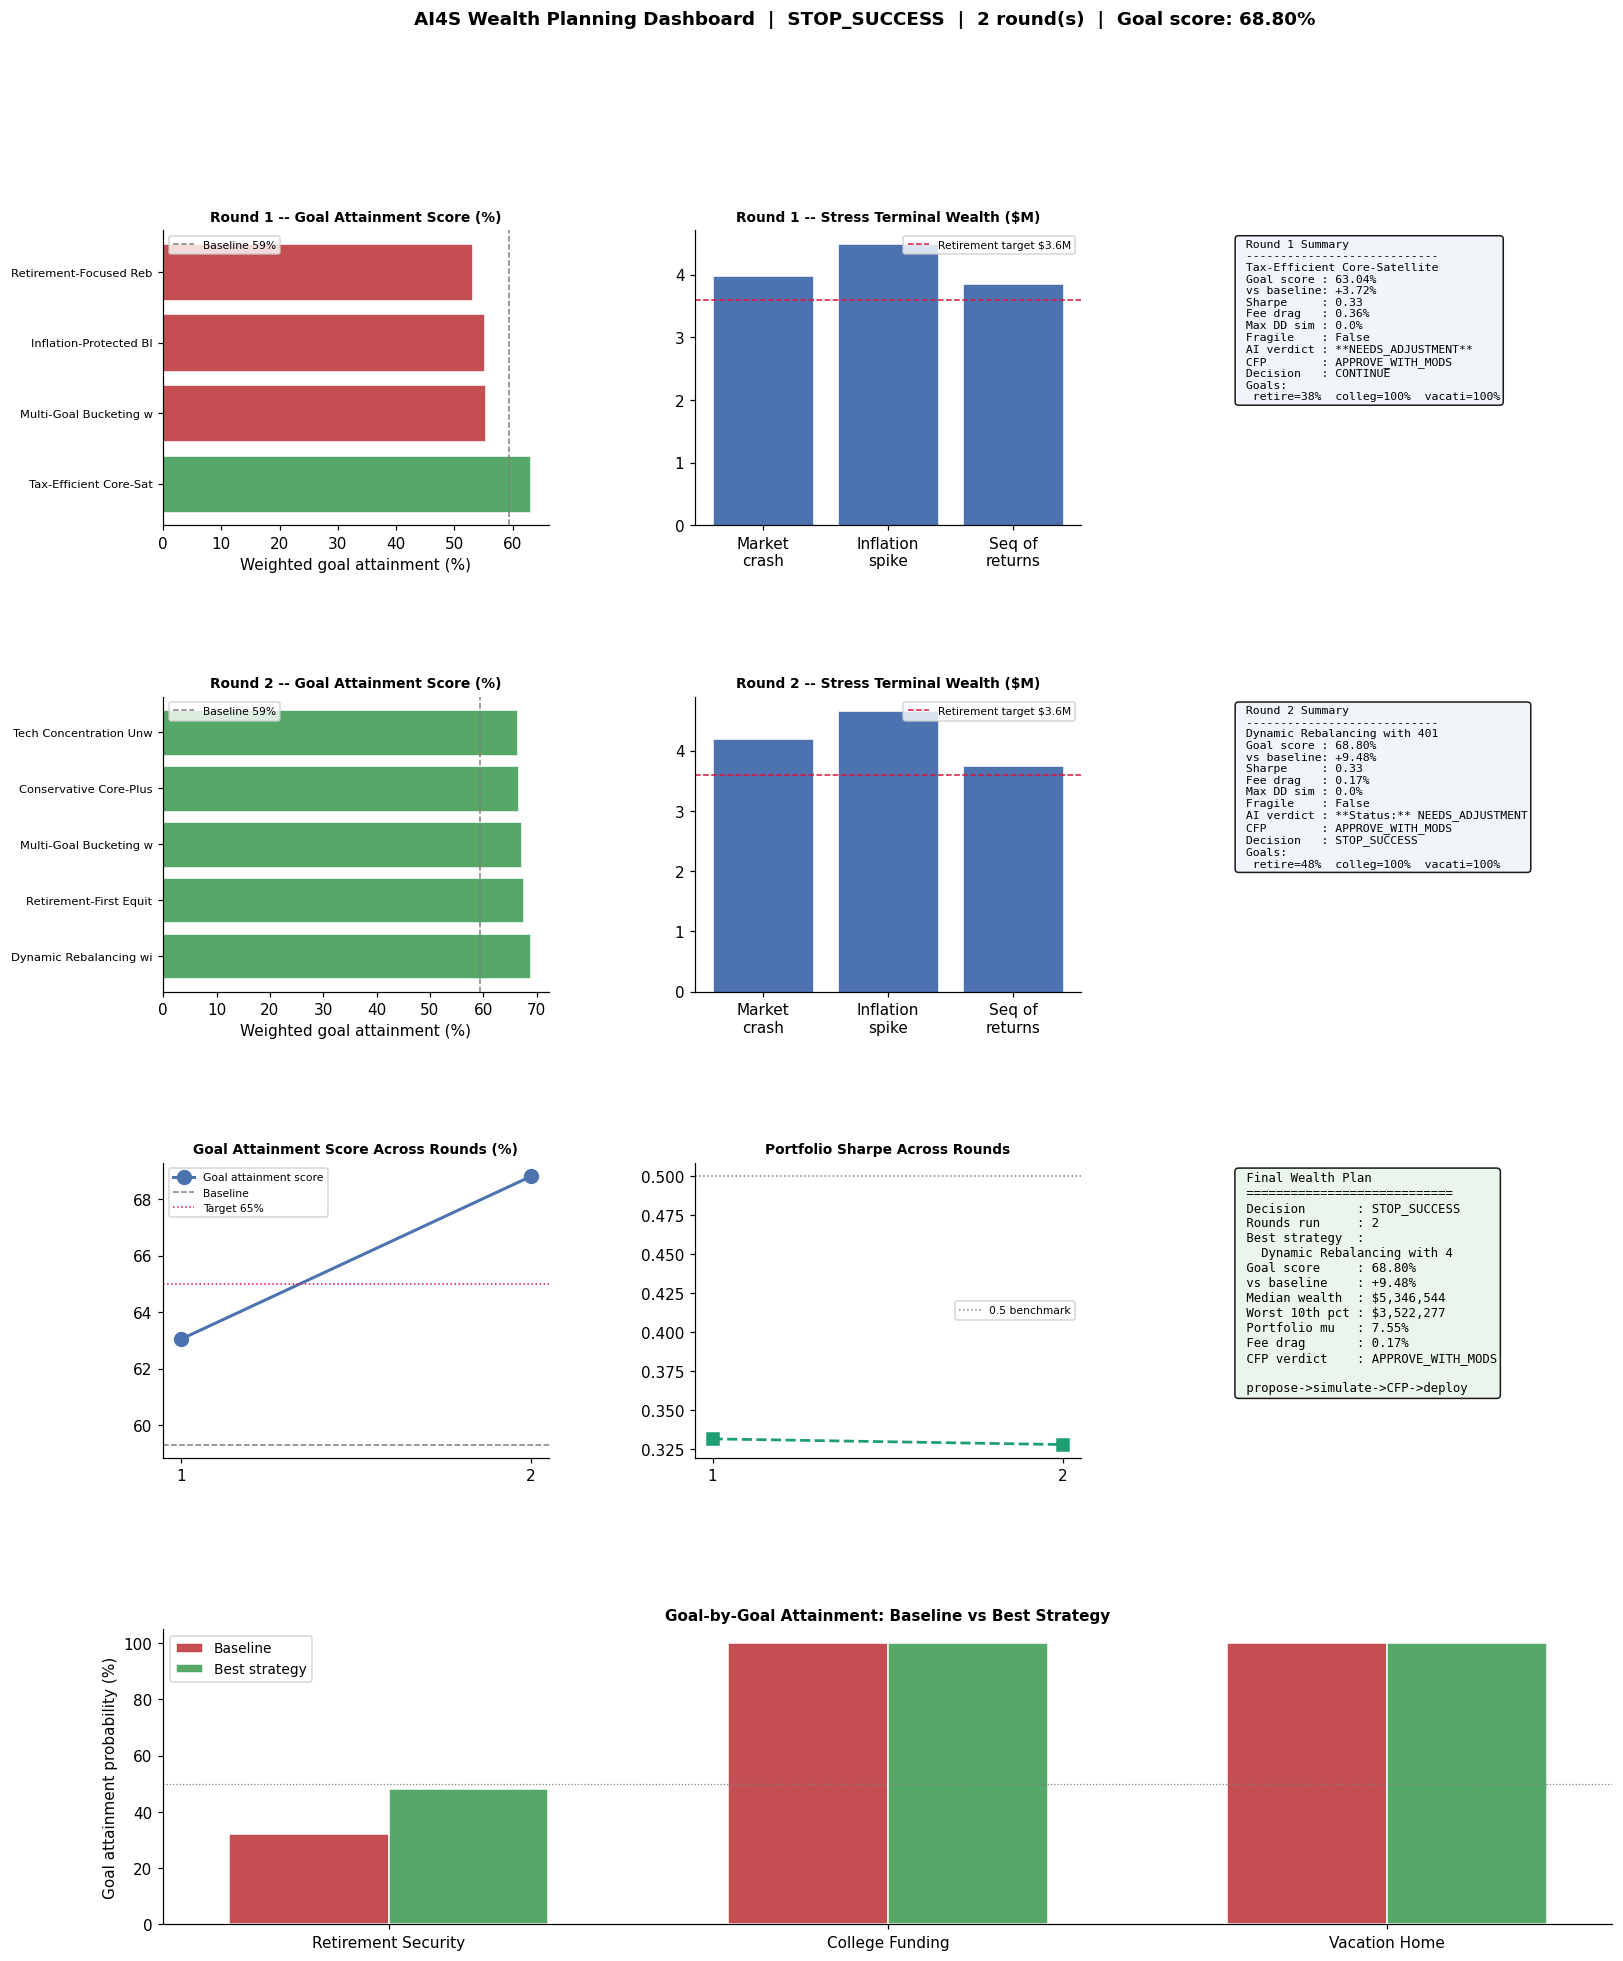


  CLIENT MEMO -- Sam & Taylor Reeves

How to present to Sam and Taylor:
  > Your retirement security goal has only a 48% success rate under this plan—that's below my comfort threshold for your primary objective. The good news: your $60k annual savings is powerful. We need to shift slightly more toward bonds in the next 2-3 years and lock in 3 years of spending in cash before you retire. This removes the panic risk of a market crash forcing us to sell low in year 1.
  > College funding and vacation home are fully locked in (100% probability), so we're not sacrificing those. The reallocation I'm recommending actually simplifies your life: fewer moving parts, lower fees, and a clearer guardrail for when markets turn ugly.
  > The catch-up contributions are a huge win—maxing Sam's $29.5k and spouse's $8k is essentially free money in tax savings. We're keeping that. But I'm stripping out the commodities bet and the underperforming active fund; they're complexity without payoff at your risk

In [39]:
# CELL 9  FINAL WEALTH PLAN DASHBOARD
# -----------------------------------------------------------------------

n_rounds = len(agent.round_results)
fig = plt.figure(figsize=(17, 6 * n_rounds + 8))
gs  = gridspec.GridSpec(n_rounds + 2, 3, figure=fig,
                        hspace=0.58, wspace=0.38)

for ri, r in enumerate(agent.round_results):
    rev = agent.advisor_reviews[ri] if ri < len(agent.advisor_reviews) else {}
    dec = agent.decision_log[ri]    if ri < len(agent.decision_log)    else {}

    # goal attainment bars
    ax1 = fig.add_subplot(gs[ri, 0])
    names  = [s['strategy']['name'][:22] for s in r.simulation_results if s['suitable']]
    scores = [s['score']                  for s in r.simulation_results if s['suitable']]
    bc     = ['#55A868' if s > baseline_result.goal_attain_score else '#C44E52'
              for s in scores]
    ax1.barh(names, [s*100 for s in scores], color=bc,
             edgecolor='white', linewidth=0.4)
    ax1.axvline(baseline_result.goal_attain_score*100, color='grey',
                ls='--', lw=1, label=f'Baseline {baseline_result.goal_attain_score:.0%}')
    ax1.set_title(f'Round {r.cycle_num} -- Goal Attainment Score (%)',
                  fontweight='bold', fontsize=9)
    ax1.set_xlabel('Weighted goal attainment (%)')
    ax1.tick_params(axis='y', labelsize=7.5)
    ax1.legend(fontsize=7)

    # stress test terminal wealth
    ax2 = fig.add_subplot(gs[ri, 1])
    sc_labels = ['Market\ncrash', 'Inflation\nspike', 'Seq of\nreturns']
    sc_vals   = [r.stress_results.get(k,{}).get('terminal',0)
                 for k in ['market_crash','inflation_spike','seq_of_returns']]
    target1   = CLIENT_PROFILE['goals'][0]['target_amount']
    sc_colors = ['#4C72B0' if v > target1*0.70 else '#C44E52' for v in sc_vals]
    bars = ax2.bar(sc_labels, [v/1e6 for v in sc_vals],
                   color=sc_colors, edgecolor='white', linewidth=0.4)
    ax2.axhline(target1/1e6, color='crimson', ls='--', lw=1,
                label=f'Retirement target ${target1/1e6:.1f}M')
    ax2.set_title(f'Round {r.cycle_num} -- Stress Terminal Wealth ($M)',
                  fontweight='bold', fontsize=9)
    ax2.legend(fontsize=7)

    # round summary text
    ax3 = fig.add_subplot(gs[ri, 2])
    ax3.axis('off')
    sim      = r.best_sim
    fb_tag   = r.feedback_verdict.splitlines()[-1] if r.feedback_verdict else 'N/A'
    gp_str   = '  '.join(f'{k[:6]}={v:.0%}' for k,v in sim.goal_probs.items()) if sim else 'N/A'
    txt = '\n'.join([
        f' Round {r.cycle_num} Summary',
        ' ' + '-'*28,
        f' {r.best_strategy.get("name","?")[:28]}',
        f' Goal score : {(sim.goal_attain_score if sim else 0):.2%}',
        f' vs baseline: {((sim.goal_attain_score if sim else 0)-baseline_result.goal_attain_score):+.2%}',
        f' Sharpe     : {(sim.portfolio_sharpe if sim else 0):.2f}',
        f' Fee drag   : {(sim.annual_fee_drag if sim else 0):.2%}',
        f' Max DD sim : {(sim.max_drawdown_sim if sim else 0):.1%}',
        f' Fragile    : {r.fragile}',
        f' AI verdict : {fb_tag}',
        f' CFP        : {rev.get("verdict","N/A")}',
        f' Decision   : {dec.get("decision","N/A")}',
        ' Goals:',
        f'  {gp_str}',
    ])
    ax3.text(0.03, 0.97, txt, transform=ax3.transAxes,
             fontsize=7.5, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f0f4fa', alpha=0.9))

# -- goal attainment evolution -----------------------------------------
rounds  = [r.cycle_num for r in agent.round_results]
scores  = [r.best_sim.goal_attain_score if r.best_sim else 0
           for r in agent.round_results]
sharpes = [r.best_sim.portfolio_sharpe  if r.best_sim else 0
           for r in agent.round_results]

axS1 = fig.add_subplot(gs[n_rounds, 0])
axS1.plot(rounds, [s*100 for s in scores], 'o-', color='#4C72B0',
          lw=2, ms=9, label='Goal attainment score')
axS1.axhline(baseline_result.goal_attain_score*100, color='grey',
             ls='--', lw=1, label='Baseline')
axS1.axhline(agent.MIN_GOAL_SCORE*100, color='crimson',
             ls=':', lw=1, label=f'Target {agent.MIN_GOAL_SCORE:.0%}')
axS1.set_title('Goal Attainment Score Across Rounds (%)',
               fontweight='bold', fontsize=9)
axS1.set_xticks(rounds)
axS1.legend(fontsize=7)

axS2 = fig.add_subplot(gs[n_rounds, 1])
axS2.plot(rounds, sharpes, 's--', color='#1D9E75', lw=1.8, ms=8)
axS2.axhline(0.5, color='grey', ls=':', lw=1, label='0.5 benchmark')
axS2.set_title('Portfolio Sharpe Across Rounds', fontweight='bold', fontsize=9)
axS2.set_xticks(rounds)
axS2.legend(fontsize=7)

# -- goal probability radar (best round) --------------------------------
axS3 = fig.add_subplot(gs[n_rounds, 2])
axS3.axis('off')
br   = best_result
bsim = br.best_sim
verdict_lines = [
    ' Final Wealth Plan',
    ' ' + '='*28,
    f' Decision       : {agent.final_decision}',
    f' Rounds run     : {n_rounds}',
    f' Best strategy  :',
    f'   {br.best_strategy.get("name","?")[:26]}',
    f' Goal score     : {(bsim.goal_attain_score if bsim else 0):.2%}',
    f' vs baseline    : {((bsim.goal_attain_score if bsim else 0)-baseline_result.goal_attain_score):+.2%}',
    f' Median wealth  : ${(bsim.terminal_median if bsim else 0):,.0f}',
    f' Worst 10th pct : ${(bsim.terminal_p10 if bsim else 0):,.0f}',
    f' Portfolio mu   : {(bsim.portfolio_mu if bsim else 0):.2%}',
    f' Fee drag       : {(bsim.annual_fee_drag if bsim else 0):.2%}',
    f' CFP verdict    : {best_review.get("verdict","N/A")}',
    '',
    ' propose->simulate->CFP->deploy',
]
axS3.text(0.03, 0.97, '\n'.join(verdict_lines),
          transform=axS3.transAxes, fontsize=8, va='top',
          fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#e8f5e9', alpha=0.9))

# -- per-goal attainment comparison (baseline vs best) ------------------
axG = fig.add_subplot(gs[n_rounds+1, :])
goal_names    = [g['name'] for g in CLIENT_PROFILE['goals']]
base_probs    = [baseline_result.goal_probs.get(g,0) for g in goal_names]
best_probs    = [bsim.goal_probs.get(g,0) for g in goal_names] if bsim else base_probs
x             = np.arange(len(goal_names))
w             = 0.32
axG.bar(x - w/2, [v*100 for v in base_probs], w,
        label='Baseline', color='#C44E52', edgecolor='white')
axG.bar(x + w/2, [v*100 for v in best_probs], w,
        label='Best strategy', color='#55A868', edgecolor='white')
axG.set_xticks(x)
axG.set_xticklabels([g.replace('_',' ').title() for g in goal_names], fontsize=10)
axG.set_ylabel('Goal attainment probability (%)')
axG.set_title('Goal-by-Goal Attainment: Baseline vs Best Strategy',
              fontweight='bold', fontsize=10)
axG.legend(fontsize=9)
axG.axhline(50, color='grey', ls=':', lw=0.8)

fig.suptitle(
    f'AI4S Wealth Planning Dashboard  |  {agent.final_decision}'
    f'  |  {n_rounds} round(s)  |  Goal score: {(bsim.goal_attain_score if bsim else 0):.2%}',
    fontsize=12, fontweight='bold'
)
plt.savefig('ai4s_wealth_dashboard.png', bbox_inches='tight', dpi=130)
plt.show()

# -- Client memo -------------------------------------------------------
print('\n' + '='*58)
print('  CLIENT MEMO -- Sam & Taylor Reeves')
print('='*58)
if best_review.get('client_talking_points'):
    print('\nHow to present to Sam and Taylor:')
    for p in best_review['client_talking_points']:
        print(f'  > {p}')
if best_review.get('behavioral_warnings'):
    print('\nBehavioural risks to address:')
    for b in best_review['behavioral_warnings']:
        print(f'  ~ {b}')
if best_review.get('next_review_triggers'):
    print('\nSchedule re-plan if:')
    for t in best_review['next_review_triggers']:
        print(f'  >> {t}')
if best_review.get('modifications'):
    print('\nRequired before implementation:')
    for m in best_review['modifications']:
        print(f'  * {m}')

##3.CONCLUSIONS

---

* Conclusion

Wealth planning has always involved a tension between quantitative rigour and
human judgment. The quantitative side — compound returns, Monte Carlo distributions,
Sharpe ratios — produces numbers that feel precise. The human side — a client's
actual risk tolerance, their behavioural biases, their willingness to hold through
a thirty-percent drawdown — produces insights that cannot be extracted from a
spreadsheet. This notebook's central claim is that the AI4S loop does not resolve
that tension. It sharpens both sides simultaneously.

* What Was Built

The Monte Carlo engine runs 1,000 simulated return paths per strategy, evaluating
goal attainment probability separately for each of Sam and Taylor's three ranked
goals. The suitability gate enforces the fiduciary standard before any strategy
reaches the simulation layer. The `WealthEvaluationAgent` governs multiple research
cycles, learning from Robert Okafor's modification requirements and the feedback
diagnosis across rounds. Together these components produce something that a
standard financial planning model does not: a ranked, stress-tested, goal-weighted
strategy recommendation that has been reviewed by a simulated fiduciary before
any number reaches the client.

* The Goal Hierarchy Matters

The decision to weight goals by client priority — retirement security at sixty
percent, college funding at twenty-eight, vacation home at twelve — is not a
technical choice. It is the encoding of a client value system into the objective
function. A system that treats all goals as equal will optimise for something
the client did not ask for. Getting the weights wrong is a form of misadvice
even if every number that follows is computed correctly. Robert's review
explicitly checks whether the AI's recommendations respect the stated hierarchy,
and his required modifications flow back into the next cycle if they do not.

* Behavioural Risk Is Not Optional

Robert's review returns behavioural warnings alongside the standard financial
analysis. This is the part of the notebook most likely to be underweighted in
a purely quantitative implementation. A strategy that is optimal in expectation
but causes the client to panic-sell during the first significant drawdown is not
actually a good strategy. The best plan is the one the client will execute, not
the one that maximises a mathematical objective. Making behavioural risk an
explicit output — one that appears in the client memo alongside the Sharpe ratio
and the goal probability — is a deliberate design choice, not an afterthought.

* The Honest Caveat

The market universe here is synthetic, the correlations are simplified, and the
regulatory rules are illustrative. Real wealth planning requires actual historical
data, tax-lot accounting, insurance analysis, estate planning integration, and
regulatory compliance with the actual jurisdiction. The purpose of this notebook
is to show the architecture — propose, simulate, advise, decide — not to produce
a filing-ready financial plan.

